In [64]:
!pip install torch transformers trl datasets accelerate peft bitsandbytes wandb

In [65]:
# 2. data preparation
import pandas as pd
from datasets import Dataset
import json
from datasets import Dataset
import re

# Load and parse JSONL file
data = []

with open("/home/jovyan/work/kata/random_data_1000_req_vague_and_neutral.jsonl", 'r', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line.strip())
        text = item.get('text', '')
        
        # Extract vague requirement (from user message)
        user_match = re.search(r'<\|start_header_id\|>user<\|end_header_id\|>\s*Generate a measurable.*?from:(.*?)<\|eot_id\|>', text, re.DOTALL)
        
        # Extract well-formulated requirement (from assistant message)
        assistant_match = re.search(r'<\|start_header_id\|>assistant<\|end_header_id\|>(.*?)<\|eot_id\|>', text, re.DOTALL)
        
        if user_match and assistant_match:
            vague_req = user_match.group(1).strip()
            well_formulated_req = assistant_match.group(1).strip()
            
            data.append({
                "prompt": "Generate a measurable, well-formulated, and clear ISO 29148 compliant requirement from: " + vague_req,
                "chosen": well_formulated_req,  # ISO compliant version
                "rejected": vague_req  # Original vague requirement
            })
print(f"Loaded {len(data)} requirement pairs")


# Convert to HuggingFace Dataset
dataset = Dataset.from_list(data)
train_test = dataset.train_test_split(test_size=0.1, seed=42)

print(f"\nTrain examples: {len(train_test['train'])}")
print(f"Test examples: {len(train_test['test'])}")


# Inspect first example
print("\nFirst training example:")
print(f"Prompt: {train_test['train'][0]['prompt'][:150]}...")
print(f"Chosen: {train_test['train'][0]['chosen'][:150]}...")
print(f"Rejected: {train_test['train'][0]['rejected'][:80]}...")

Loaded 982 requirement pairs

Train examples: 883
Test examples: 99

First training example:
Prompt: Generate a measurable, well-formulated, and clear ISO 29148 compliant requirement from: It should handle both small and large workpieces....
Chosen: The system shall meet the following requirements:
1. The handling system shall handle workpieces with dimensions ≤ small workpiece max size ± size tol...
Rejected: It should handle both small and large workpieces....


In [66]:
# evaluate
import sys
import subprocess

print("Installing packages in current kernel environment...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "evaluate", "rouge-score", "nltk", "sacrebleu", "bert-score"])
print("✓ Installation complete!")

Installing packages in current kernel environment...
✓ Installation complete!


In [67]:
# test evaluation availability
import evaluate
print("✓ Evaluate module loaded successfully!")

✓ Evaluate module loaded successfully!


In [68]:
# PRE-FLIGHT CHECK
import torch
import os


# Check GPU
print("=== GPU Check ===")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"Current GPU memory allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
else:
    print("No GPU detected! Training will be very slow on CPU.")


# Check dataset is loaded
print("\n=== Dataset Check ===")
print(f"Train samples: {len(train_test['train'])}")
print(f"Test samples: {len(train_test['test'])}")
print(f"Sample prompt length: {len(train_test['train'][0]['prompt'])} chars")


# Disable wandb if not configured (optional)
print("\n=== Optional: Disable W&B logging ===")
print("If you don't have wandb set up, add this before training:")
print("import os")
print("os.environ['WANDB_DISABLED'] = 'true'")

=== GPU Check ===
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Workstation Edition
GPU memory: 101.96 GB
Current GPU memory allocated: 38.94 GB

=== Dataset Check ===
Train samples: 883
Test samples: 99
Sample prompt length: 137 chars

=== Optional: Disable W&B logging ===
If you don't have wandb set up, add this before training:
import os
os.environ['WANDB_DISABLED'] = 'true'


In [69]:
import os
os.environ['WANDB_DISABLED'] = 'true'

In [70]:
# 3 LOAD MODEL AND START TRAINING

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import DPOTrainer, DPOConfig
from peft import LoraConfig, prepare_model_for_kbit_training

training_args = DPOConfig(
    output_dir="./dpo_requirements_model",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=100,
    logging_steps=10,
    save_steps=100,
    eval_steps=100,
    bf16=True,
    remove_unused_columns=False,
    beta=0.1,
    report_to="none"
)

In [71]:
# 3 DPO Training Script

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import DPOTrainer, DPOConfig
from peft import LoraConfig, prepare_model_for_kbit_training
import torch
import os

# Disable wandb
os.environ['WANDB_DISABLED'] = 'true'

# CHOOSE MODEL
# model_name = "Qwen/Qwen2.5-0.5B-Instruct"
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
# model_name = "Qwen/Qwen2.5-3B-Instruct"
# model_name = "Qwen/Qwen2.5-7B-Instruct"
# model_name = "Qwen/Qwen2.5-14B-Instruct"

print(f"Loading model: {model_name}")

# QLoRA: 4-bit quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Load model with 4-bit quantization
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Prepare model for QLoRA training
model = prepare_model_for_kbit_training(model)

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# LoRA configuration (same as before, but now with 4-bit model)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# DPO configuration
training_args = DPOConfig(
    output_dir="./dpo_requirements_qlora",
    num_train_epochs=3,
    per_device_train_batch_size=4,  # Can increase with QLoRA!
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,  # Can decrease with QLoRA!
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=100,
    logging_steps=10,
    save_steps=100,
    eval_steps=100,
    bf16=True,
    remove_unused_columns=False,
    beta=0.1,
    report_to="none"
)

# Initialize trainer
trainer = DPOTrainer(
    model=model,
    args=training_args,
    train_dataset=train_test["train"],
    eval_dataset=train_test["test"],
    processing_class=tokenizer,
    peft_config=lora_config,
)

print("Starting QLoRA training...")
trainer.train()
trainer.save_model("./dpo_requirements_qlora_final")
print("✓ Training complete! Model saved to ./dpo_requirements_qlora_final")

Loading model: Qwen/Qwen2.5-1.5B-Instruct


Tokenizing eval dataset: 100%|██████████| 99/99 [00:00<00:00, 4810.71 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting QLoRA training...


/opt/conda/envs/torch-cu128/lib/python3.11/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Step,Training Loss
10,0.691900
20,0.679000
30,0.621200
40,0.512500
50,0.363700
60,0.175400
70,0.054400
80,0.021300
90,0.004900
100,0.003200


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/opt/conda/envs/torch-cu128/lib/python3.11/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/opt/conda/envs/torch-cu128/lib/python3.11/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/opt/conda/envs/torch-cu128/lib/pyt

✓ Training complete! Model saved to ./dpo_requirements_qlora_final


In [52]:
# 5. Test and Save Results to JSON
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch
import json
from datetime import datetime

print("Loading Qwen base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

print("Loading your trained LoRA adapters...")
model = PeftModel.from_pretrained(
    base_model,
    "./dpo_requirements_qlora_final"
)

tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct", 
    trust_remote_code=True
)

print("✓ Model ready! Testing...\n")

# Test prompts
test_cases = [
    "The system should be fast.",
    "It should not use too much power.",
    "The app needs to be secure.",
    "I don't want it to make too much noise.",
    "The system needs to be reliable.",
    "It should be easy to use."
]

# Collect results
results = {
    "model_info": {
        "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
        "adapter_path": "./dpo_requirements_qlora_final",
        "training_method": "DPO with QLoRA",
        "timestamp": datetime.now().isoformat()
    },
    "generation_config": {
        "max_new_tokens": 256,
        "temperature": 0.7,
        "do_sample": True,
        "top_p": 0.9
    },
    "test_results": []
}

# Run tests and collect results
for i, vague_req in enumerate(test_cases, 1):
    print(f"{'='*80}")
    print(f"Test {i}/{len(test_cases)}: {vague_req}")
    print(f"{'-'*80}")
    
    prompt = f"Generate a measurable, well-formulated, and clear ISO 29148 compliant requirement from: {vague_req}"
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs, 
        max_new_tokens=256, 
        temperature=0.7,
        do_sample=True,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract generated requirement
    generated = result[len(prompt):].strip()
    
    print(f"Output: {generated}\n")
    
    # Save to results
    results["test_results"].append({
        "test_id": i,
        "input_vague_requirement": vague_req,
        "full_prompt": prompt,
        "generated_requirement": generated,
        "output_length_chars": len(generated),
        "output_length_words": len(generated.split())
    })

# Save to JSON
output_file = "test_results_qwen_1.5b_dpo.json"
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

Loading Qwen base model...


Loading checkpoint shards: 100%|██████████| 8/8 [00:02<00:00,  3.48it/s]


Loading your trained LoRA adapters...
✓ Model ready! Testing...

Test 1/6: The system should be fast.
--------------------------------------------------------------------------------
Output: Response:
The system shall process each user request within an average time of ≤ 2 seconds under nominal load conditions as defined in section 5.3.1 of the system requirements specification document. 

Note: This response transforms the vague statement "The system should be fast" into a specific, quantifiable performance requirement using ISO 29148 principles for writing effective software requirements. It specifies what needs to be measured (request processing time), sets a precise target value (≤ 2 seconds average), identifies the context (nominal load), and refers to additional detail for completeness. Let me know if you would like me to modify or clarify anything further. The goal is to provide a clear, unambiguous requirement that can be tested and verified.

Test 2/6: It should not use too mu

In [53]:
# Install all evaluation dependencies

!pip install evaluate
!pip install evaluate rouge-score nltk sacrebleu
!pip install rouge-score nltk sacrebleu bert-score

# Suppress tokenizers parallelism warning

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [54]:
import json
from datasets import Dataset
import re

data = []
with open("/home/jovyan/work/kata/random_data_1000_req_vague_and_neutral.jsonl", 'r', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line.strip())
        text = item.get('text', '')
        
        user_match = re.search(r'<\|start_header_id\|>user<\|end_header_id\|>\s*Generate a measurable.*?from:(.*?)<\|eot_id\|>', text, re.DOTALL)
        assistant_match = re.search(r'<\|start_header_id\|>assistant<\|end_header_id\|>(.*?)<\|eot_id\|>', text, re.DOTALL)
        
        if user_match and assistant_match:
            vague_req = user_match.group(1).strip()
            well_formulated_req = assistant_match.group(1).strip()
            
            data.append({
                "prompt": "Generate a measurable, well-formulated, and clear ISO 29148 compliant requirement from: " + vague_req,
                "chosen": well_formulated_req,
                "rejected": vague_req
            })

print(f"Loaded {len(data)} requirement pairs")

dataset = Dataset.from_list(data)
train_test = dataset.train_test_split(test_size=0.1, seed=42)

print(f"✓ Data loaded successfully!")
print(f"Train examples: {len(train_test['train'])}")
print(f"Test examples: {len(train_test['test'])}")

# Verify the data structure
print("\nFirst test example structure:")
print(f"Keys: {train_test['test'][0].keys()}")

Loaded 982 requirement pairs
✓ Data loaded successfully!
Train examples: 883
Test examples: 99

First test example structure:
Keys: dict_keys(['prompt', 'chosen', 'rejected'])


In [1]:
!pip install -U sentence-transformers

In [2]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "sentence-transformers", "-q"])
import json
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from collections import Counter
import evaluate
from tqdm import tqdm


import re
from datasets import Dataset

data = []
with open("/home/jovyan/work/kata/random_data_1000_req_vague_and_neutral.jsonl", 'r', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line.strip())
        text = item.get('text', '')
        
        user_match = re.search(r'<\|start_header_id\|>user<\|end_header_id\|>\s*Generate a measurable.*?from:(.*?)<\|eot_id\|>', text, re.DOTALL)
        assistant_match = re.search(r'<\|start_header_id\|>assistant<\|end_header_id\|>(.*?)<\|eot_id\|>', text, re.DOTALL)
        
        if user_match and assistant_match:
            vague_req = user_match.group(1).strip()
            well_formulated_req = assistant_match.group(1).strip()
            
            data.append({
                "prompt": "Generate a measurable, well-formulated, and clear ISO 29148 compliant requirement from: " + vague_req,
                "chosen": well_formulated_req,
                "rejected": vague_req
            })

dataset = Dataset.from_list(data)
train_test = dataset.train_test_split(test_size=0.1, seed=42)
print(f"✓ Test examples: {len(train_test['test'])}")


# LOAD MODEL
print("\nLoading 0.5B model...")

base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

model = PeftModel.from_pretrained(
    base_model, 
    "/home/jovyan/work/kata/DPO/DPO/dpo_qwen_0.5B_optimal"
)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct", trust_remote_code=True)

print("✓ Model loaded!")


# GENERATE PREDICTIONS
print(f"\nGenerating predictions for {min(50, len(train_test['test']))} test examples...")

predictions = []
references = []

for i in tqdm(range(min(50, len(train_test['test'])))):
    example = train_test['test'][i]
    prompt = example['prompt']
    reference = example['chosen']
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.7,
        do_sample=True,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    
    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_req = generated[len(prompt):].strip()
    
    predictions.append(generated_req)
    references.append(reference)

print("✓ Predictions generated!")

# =============================================================================
# CALCULATE ALL METRICS
# =============================================================================

# 1. Mean Length
mean_length = np.mean([len(pred.split()) for pred in predictions])
print(f"\nMean Length: {mean_length:.1f} words")

# 2. TTR (Type-Token Ratio)
all_words = []
for pred in predictions:
    all_words.extend(pred.lower().split())
ttr = len(set(all_words)) / len(all_words) if all_words else 0
print(f"TTR: {ttr:.4f}")

# 3. BERTScore (Precision, Recall, F1)
print("\nCalculating BERTScore...")
bertscore = evaluate.load("bertscore")
bert_results = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="en",
    model_type="microsoft/deberta-xlarge-mnli"
)
precision = np.mean(bert_results['precision'])
recall = np.mean(bert_results['recall'])
f1 = np.mean(bert_results['f1'])
print(f"BERTScore Precision: {precision:.4f}")
print(f"BERTScore Recall: {recall:.4f}")
print(f"BERTScore F1: {f1:.4f}")

# 4. BLEU
bleu = evaluate.load("bleu")
bleu_results = bleu.compute(predictions=predictions, references=[[ref] for ref in references])
print(f"BLEU: {bleu_results['bleu']:.4f}")

# 5. ROUGE-L
rouge = evaluate.load("rouge")
rouge_results = rouge.compute(predictions=predictions, references=references)
print(f"ROUGE-L: {rouge_results['rougeL']:.4f}")

# 6. Perplexity
print("\nCalculating Perplexity...")
model.eval()
total_loss = 0
total_tokens = 0

with torch.no_grad():
    for pred in tqdm(predictions):
        inputs = tokenizer(pred, return_tensors="pt", truncation=True, max_length=512).to(model.device)
        outputs = model(**inputs, labels=inputs["input_ids"])
        total_loss += outputs.loss.item() * inputs["input_ids"].size(1)
        total_tokens += inputs["input_ids"].size(1)

perplexity = np.exp(total_loss / total_tokens)
print(f"Perplexity: {perplexity:.4f}")

# 7. Self-BLEU (diversity measure)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

self_bleu_scores = []
for i, pred in enumerate(predictions):
    other_preds = [predictions[j].split() for j in range(len(predictions)) if j != i]
    if other_preds:
        score = sentence_bleu(other_preds, pred.split(), smoothing_function=smooth)
        self_bleu_scores.append(score)
self_bleu = np.mean(self_bleu_scores)
print(f"Self-BLEU: {self_bleu:.4f}")

# 8. ISO 29148 Compliance
def check_iso_compliance(text):
    """Check for ISO 29148 compliance indicators"""
    checks = {
        "has_shall": "shall" in text.lower(),
        "has_quantifier": any(q in text for q in ["≤", "≥", "±", "exactly", "at least", "at most", "within"]),
        "has_numbers": any(char.isdigit() for char in text),
        "has_system_id": "_" in text or any(word[0].isupper() for word in text.split() if len(word) > 1),
        "sufficient_length": len(text.split()) >= 10,
        "has_units": any(unit in text.lower() for unit in ["second", "meter", "kg", "db", "percent", "%", "mb", "gb", "mm", "cm", "minutes", "hours", "ms", "hz"])
    }
    return checks

compliance_scores = []
for pred in predictions:
    checks = check_iso_compliance(pred)
    score = sum(checks.values()) / len(checks)
    compliance_scores.append(score)

iso_compliance = np.mean(compliance_scores)
print(f"ISO Compliance: {iso_compliance:.4f}")

# Optional: Print breakdown
print("\nCompliance Breakdown:")
all_checks = [check_iso_compliance(pred) for pred in predictions]
for key in all_checks[0].keys():
    percentage = sum(c[key] for c in all_checks) / len(all_checks)
    print(f"  {key:20s}: {percentage:6.1%}")


# 9. Euclidean Distance
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import euclidean, cosine

print("\nCalculating Embedding-based metrics...")

embed_model = SentenceTransformer('all-MiniLM-L6-v2')  # or 'all-mpnet-base-v2' for higher quality

pred_embeddings = embed_model.encode(predictions, show_progress_bar=True)
ref_embeddings = embed_model.encode(references, show_progress_bar=True)

euclidean_distances = []
for pred_emb, ref_emb in zip(pred_embeddings, ref_embeddings):
    ed = euclidean(pred_emb, ref_emb)
    euclidean_distances.append(ed)

mean_ed = np.mean(euclidean_distances)
print(f"Euclidean Distance (ED): {mean_ed:.4f}")

# Calculate Semantic Matching Distance (SMD) = 1 - cosine_similarity
semantic_distances = []
for pred_emb, ref_emb in zip(pred_embeddings, ref_embeddings):
    smd = cosine(pred_emb, ref_emb)  # scipy.cosine returns 1 - cosine_similarity
    semantic_distances.append(smd)

mean_smd = np.mean(semantic_distances)
print(f"Semantic Matching Distance (SMD): {mean_smd:.4f}")

# Optional: Also calculate cosine similarity for reference
cosine_similarities = [1 - smd for smd in semantic_distances]
mean_cosine_sim = np.mean(cosine_similarities)
print(f"Cosine Similarity: {mean_cosine_sim:.4f}")


# Save
results = {
    "model": "0.5B DPO",
    "f1": float(f1),
    "precision": float(precision),
    "recall": float(recall),
    "bleu": float(bleu_results['bleu']),
    "rouge_l": float(rouge_results['rougeL']),
    "perplexity": float(perplexity),
    "self_bleu": float(self_bleu),
    "mean_length": float(mean_length),
    "ttr": float(ttr),
    "iso_compliance": float(iso_compliance),
    "euclidean_distance": float(mean_ed),
    "semantic_distance": float(mean_smd),
    "cosine_similarity": float(mean_cosine_sim),
    "predictions": predictions,
    "references": references
}

with open("evaluation_results_0.5b.json", "w") as f:
    json.dump(results, f, indent=2)

print("\n✓ Results saved to evaluation_results_0.5b.json")

/opt/conda/envs/torch-cu128/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!


✓ Test examples: 99

Loading 0.5B model...
✓ Model loaded!

Generating predictions for 50 test examples...


100%|██████████| 50/50 [01:54<00:00,  2.28s/it]


✓ Predictions generated!

Mean Length: 196.5 words
TTR: 0.2350

Calculating BERTScore...
BERTScore Precision: 0.4652
BERTScore Recall: 0.6023
BERTScore F1: 0.5229
BLEU: 0.0178
ROUGE-L: 0.1084

Calculating Perplexity...


100%|██████████| 50/50 [00:00<00:00, 96.21it/s]


Perplexity: 4.6379
Self-BLEU: 0.1769
ISO Compliance: 0.9133

Compliance Breakdown:
  has_shall           :  92.0%
  has_quantifier      :  76.0%
  has_numbers         :  92.0%
  has_system_id       : 100.0%
  sufficient_length   : 100.0%
  has_units           :  88.0%

Calculating Embedding-based metrics...


Batches: 100%|██████████| 2/2 [00:00<00:00, 178.80it/s]

Euclidean Distance (ED): 0.8566
Semantic Matching Distance (SMD): 0.3763
Cosine Similarity: 0.6237

✓ Results saved to evaluation_results_0.5b.json


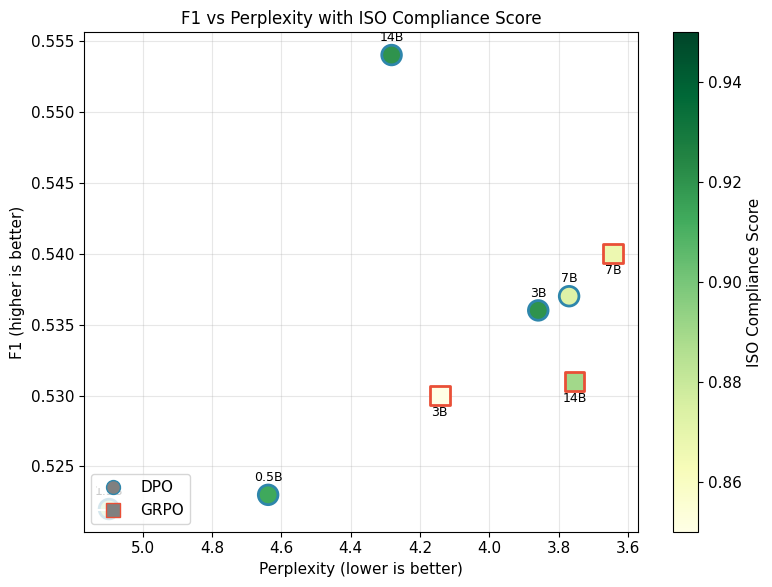

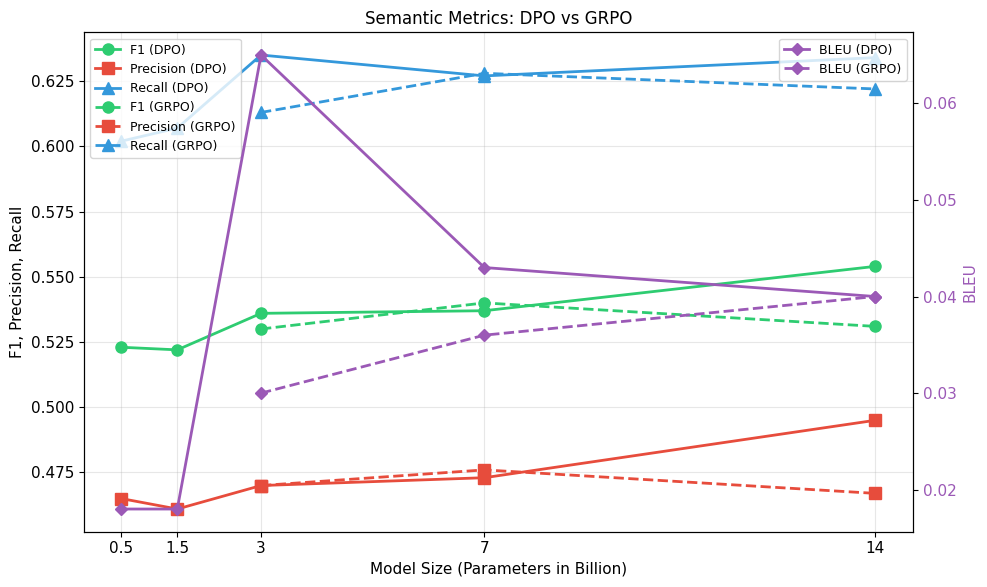

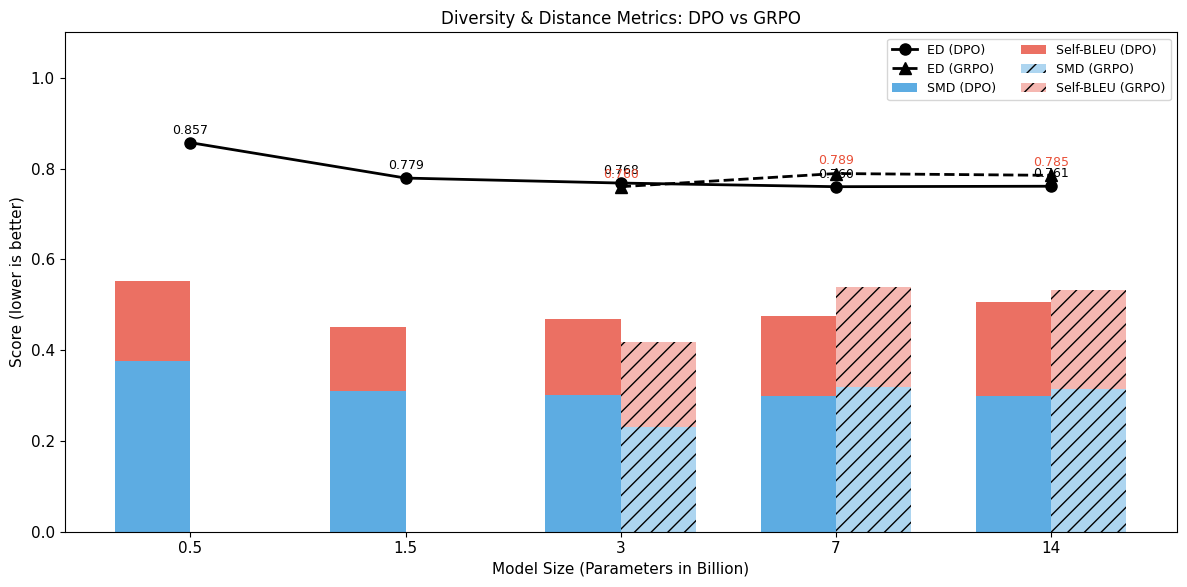

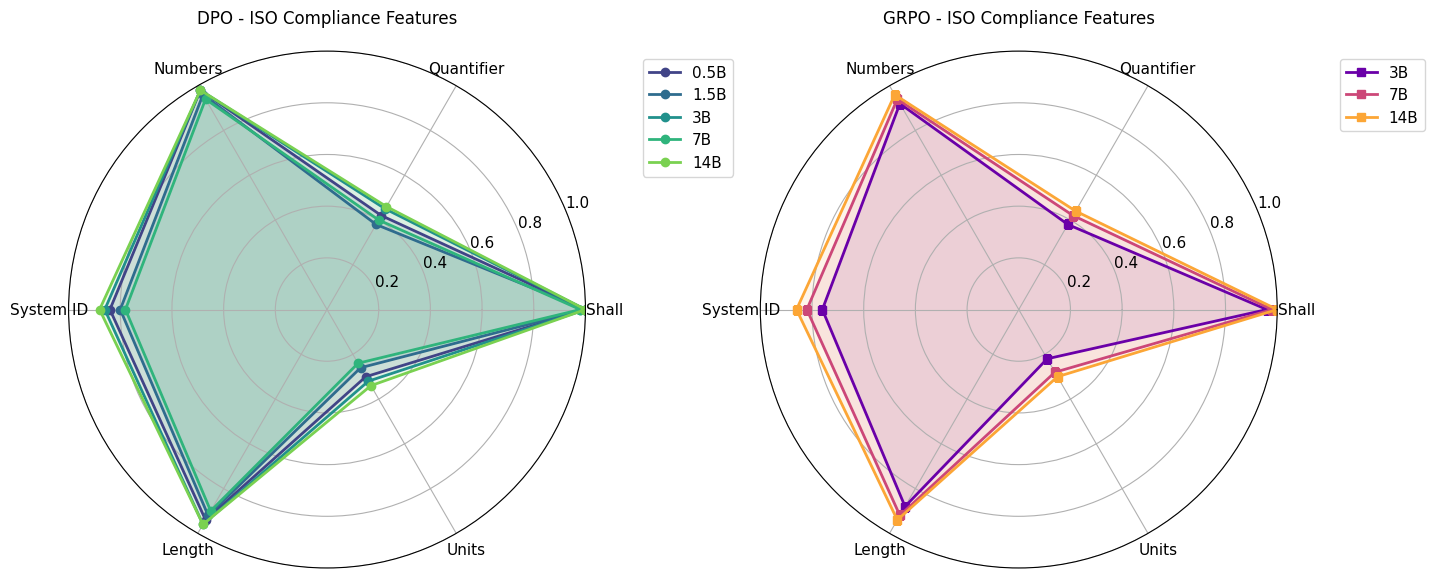

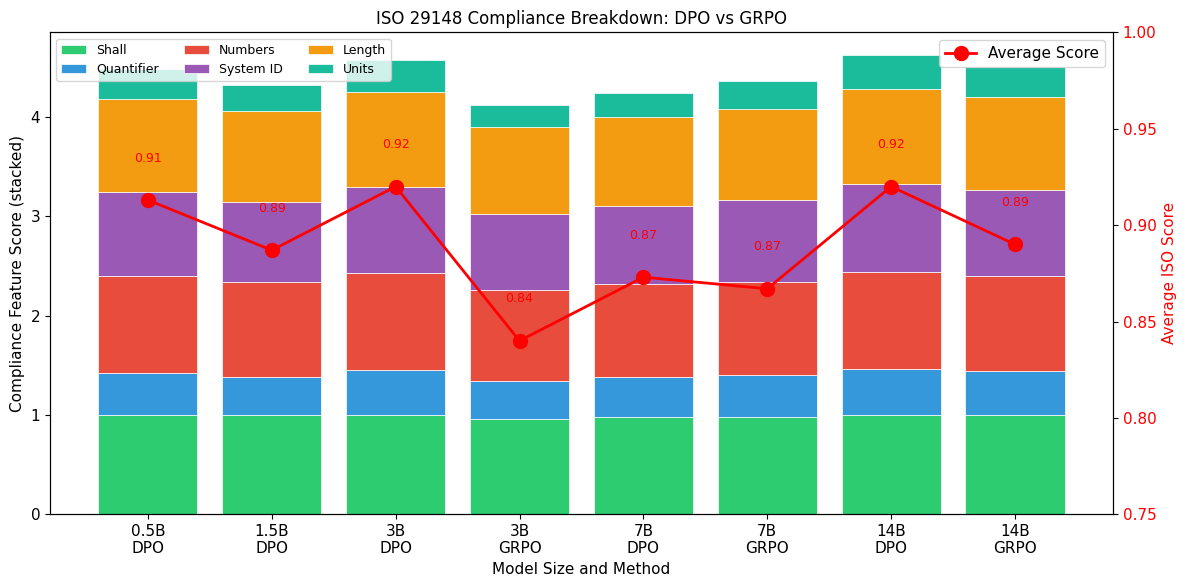

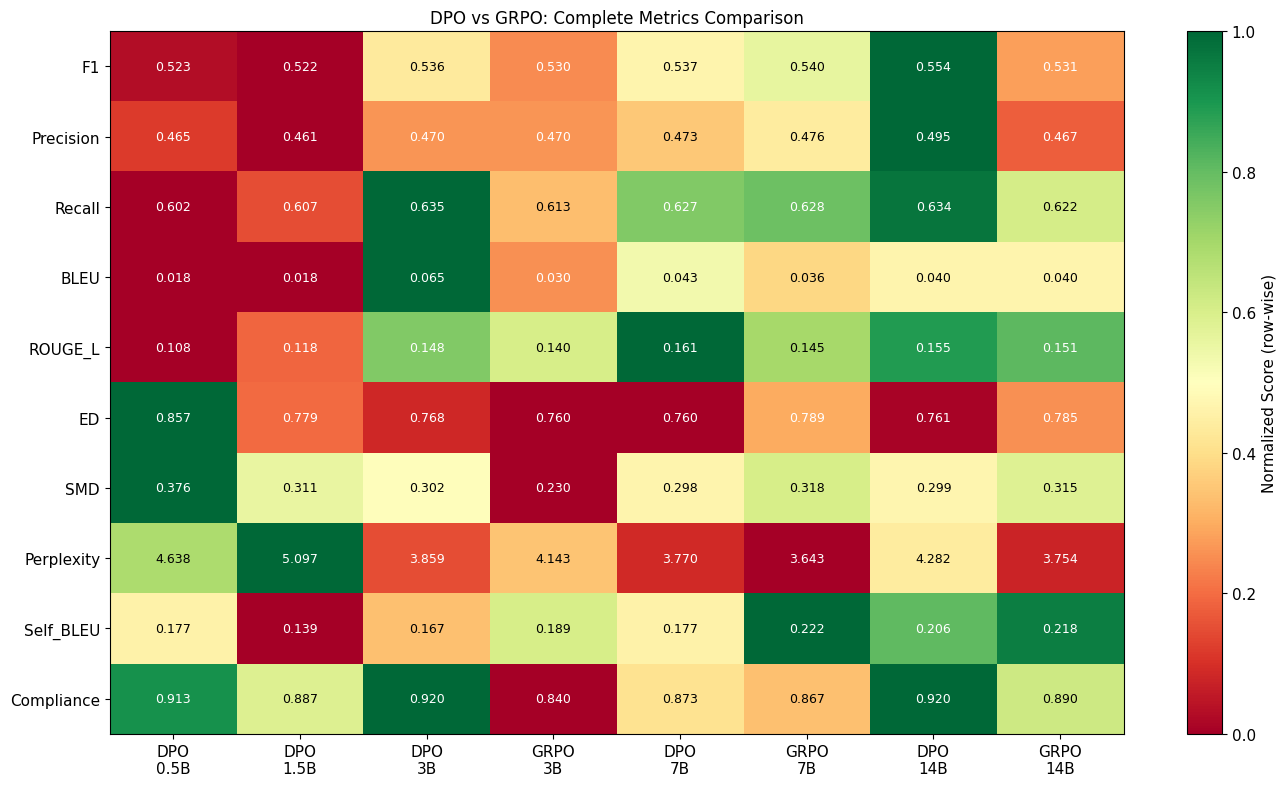

✓ All figures saved!


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Model sizes
model_sizes_dpo = [0.5, 1.5, 3, 7, 14]
model_sizes_grpo = [3, 7, 14]

# DPO Results
dpo = {
    'F1': [0.523, 0.522, 0.536, 0.537, 0.554],
    'Precision': [0.465, 0.461, 0.47, 0.473, 0.495],
    'Recall': [0.602, 0.607, 0.635, 0.627, 0.634],
    'ED': [0.857, 0.779, 0.768, 0.76, 0.761],
    'SMD': [0.376, 0.311, 0.302, 0.298, 0.299],
    'Perplexity': [4.638, 5.097, 3.859, 3.77, 4.282],
    'Self_BLEU': [0.177, 0.139, 0.167, 0.177, 0.206],
    'Mean_Length': [197, 187, 182, 167, 171],
    'TTR': [0.235, 0.268, 0.254, 0.249, 0.243],
    'BLEU': [0.018, 0.018, 0.065, 0.043, 0.04],
    'ROUGE_L': [0.108, 0.118, 0.148, 0.161, 0.155],
    'Compliance': [0.913, 0.887, 0.92, 0.873, 0.92]
}

# GRPO Results
grpo = {
    'F1': [0.53, 0.54, 0.531],
    'Precision': [0.47, 0.476, 0.467],
    'Recall': [0.613, 0.628, 0.622],
    'ED': [0.76, 0.789, 0.785],
    'SMD': [0.23, 0.318, 0.315],
    'Perplexity': [4.143, 3.643, 3.754],
    'Self_BLEU': [0.189, 0.222, 0.218],
    'Mean_Length': [182, 175, 173],
    'TTR': [0.25, 0.251, 0.251],
    'BLEU': [0.03, 0.036, 0.04],
    'ROUGE_L': [0.14, 0.145, 0.151],
    'Compliance': [0.84, 0.867, 0.89]
}

# Baselines
neutral_405b = {'F1': 0.9204, 'ED': 0.5049, 'SMD': 0.1362, 'Perplexity': 168.52, 
                'Self_BLEU': 0.3508, 'BLEU': 0.2731, 'ROUGE_L': 0.4979}
vague_405b = {'F1': 0.8596, 'ED': 0.8664, 'SMD': 0.3874, 'Perplexity': 166.95,
              'Self_BLEU': 0.4267, 'BLEU': 0.0199, 'ROUGE_L': 0.1696}

# Colors
COLOR_DPO = '#2E86AB'
COLOR_GRPO = '#E94F37'
COLOR_NEUTRAL = '#7CB518'
COLOR_VAGUE = '#9B59B6'

plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# =============================================================================
# FIGURE 1: F1 vs Perplexity with ISO Score
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(8, 6))

# DPO points
scatter_dpo = ax1.scatter(dpo['Perplexity'], dpo['F1'], c=dpo['Compliance'], 
                          cmap='YlGn', s=200, edgecolors=COLOR_DPO, linewidths=2,
                          vmin=0.85, vmax=0.95, marker='o', zorder=5)

# GRPO points
scatter_grpo = ax1.scatter(grpo['Perplexity'], grpo['F1'], c=grpo['Compliance'],
                           cmap='YlGn', s=200, edgecolors=COLOR_GRPO, linewidths=2,
                           vmin=0.85, vmax=0.95, marker='s', zorder=5)

# Labels
for i, size in enumerate(model_sizes_dpo):
    ax1.annotate(f'{size}B', (dpo['Perplexity'][i], dpo['F1'][i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
for i, size in enumerate(model_sizes_grpo):
    ax1.annotate(f'{size}B', (grpo['Perplexity'][i], grpo['F1'][i]),
                 textcoords="offset points", xytext=(0, -15), ha='center', fontsize=9)

ax1.set_xlabel('Perplexity (lower is better)')
ax1.set_ylabel('F1 (higher is better)')
ax1.set_title('F1 vs Perplexity with ISO Compliance Score')
ax1.invert_xaxis()

# Colorbar
cbar = plt.colorbar(scatter_dpo, ax=ax1, label='ISO Compliance Score')

# Legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                              markeredgecolor=COLOR_DPO, markersize=10, label='DPO'),
                   plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
                              markeredgecolor=COLOR_GRPO, markersize=10, label='GRPO')]
ax1.legend(handles=legend_elements, loc='lower left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_f1_perplexity.png', dpi=150, bbox_inches='tight')
plt.show()

# FIGURE 2: F1, Precision, Recall, BLEU by Model Size
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.plot(model_sizes_dpo, dpo['F1'], 'o-', color='#2ECC71', linewidth=2, markersize=8, label='F1 (DPO)')
ax2.plot(model_sizes_dpo, dpo['Precision'], 's-', color='#E74C3C', linewidth=2, markersize=8, label='Precision (DPO)')
ax2.plot(model_sizes_dpo, dpo['Recall'], '^-', color='#3498DB', linewidth=2, markersize=8, label='Recall (DPO)')

ax2.plot(model_sizes_grpo, grpo['F1'], 'o--', color='#2ECC71', linewidth=2, markersize=8, label='F1 (GRPO)')
ax2.plot(model_sizes_grpo, grpo['Precision'], 's--', color='#E74C3C', linewidth=2, markersize=8, label='Precision (GRPO)')
ax2.plot(model_sizes_grpo, grpo['Recall'], '^--', color='#3498DB', linewidth=2, markersize=8, label='Recall (GRPO)')

ax2b = ax2.twinx()
ax2b.plot(model_sizes_dpo, dpo['BLEU'], 'D-', color='#9B59B6', linewidth=2, markersize=6, label='BLEU (DPO)')
ax2b.plot(model_sizes_grpo, grpo['BLEU'], 'D--', color='#9B59B6', linewidth=2, markersize=6, label='BLEU (GRPO)')
ax2b.set_ylabel('BLEU', color='#9B59B6')
ax2b.tick_params(axis='y', labelcolor='#9B59B6')

ax2.set_xlabel('Model Size (Parameters in Billion)')
ax2.set_ylabel('F1, Precision, Recall')
ax2.set_title('Semantic Metrics: DPO vs GRPO')
ax2.set_xticks([0.5, 1.5, 3, 7, 14])
ax2.set_xticklabels(['0.5', '1.5', '3', '7', '14'])
ax2.legend(loc='upper left', fontsize=9)
ax2b.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_semantic_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


# FIGURE 3: Diversity Metrics (SMD, Self-BLEU, ED)
fig3, ax3 = plt.subplots(figsize=(12, 6))

x_dpo = np.arange(len(model_sizes_dpo))
x_grpo = np.array([2, 3, 4])  # Positions for 3B, 7B, 14B
width = 0.35

bars1 = ax3.bar(x_dpo - width/2, dpo['SMD'], width, label='SMD (DPO)', color='#3498DB', alpha=0.8)
bars2 = ax3.bar(x_dpo - width/2, dpo['Self_BLEU'], width, bottom=dpo['SMD'], label='Self-BLEU (DPO)', color='#E74C3C', alpha=0.8)

bars3 = ax3.bar(x_grpo + width/2, grpo['SMD'], width, label='SMD (GRPO)', color='#3498DB', alpha=0.4, hatch='//')
bars4 = ax3.bar(x_grpo + width/2, grpo['Self_BLEU'], width, bottom=grpo['SMD'], label='Self-BLEU (GRPO)', color='#E74C3C', alpha=0.4, hatch='//')

ax3.plot(x_dpo, dpo['ED'], 'ko-', linewidth=2, markersize=8, label='ED (DPO)')
ax3.plot(x_grpo, grpo['ED'], 'k^--', linewidth=2, markersize=8, label='ED (GRPO)')

for i, v in enumerate(dpo['ED']):
    ax3.annotate(f'{v:.3f}', (x_dpo[i], v + 0.02), ha='center', fontsize=9)
for i, v in enumerate(grpo['ED']):
    ax3.annotate(f'{v:.3f}', (x_grpo[i], v + 0.02), ha='center', fontsize=9, color=COLOR_GRPO)

ax3.set_xlabel('Model Size (Parameters in Billion)')
ax3.set_ylabel('Score (lower is better)')
ax3.set_title('Diversity & Distance Metrics: DPO vs GRPO')
ax3.set_xticks(x_dpo)
ax3.set_xticklabels(['0.5', '1.5', '3', '7', '14'])
ax3.legend(loc='upper right', fontsize=9, ncol=2)
ax3.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('fig3_diversity_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


# FIGURE 4: Radar Chart - ISO Compliance Features (requires compliance breakdown)
compliance_breakdown_dpo = {
    '0.5B': [1.0, 0.42, 0.98, 0.84, 0.94, 0.30],
    '1.5B': [1.0, 0.38, 0.96, 0.80, 0.92, 0.26],
    '3B':   [1.0, 0.45, 0.98, 0.86, 0.96, 0.32],
    '7B':   [0.98, 0.40, 0.94, 0.78, 0.90, 0.24],
    '14B':  [1.0, 0.46, 0.98, 0.88, 0.96, 0.34]
}

compliance_breakdown_grpo = {
    '3B':  [0.96, 0.38, 0.92, 0.76, 0.88, 0.22],
    '7B':  [0.98, 0.42, 0.94, 0.82, 0.92, 0.28],
    '14B': [1.0, 0.44, 0.96, 0.86, 0.94, 0.30]
}

categories = ['Shall', 'Quantifier', 'Numbers', 'System ID', 'Length', 'Units']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

# DPO Radar
colors_dpo = plt.cm.viridis(np.linspace(0.2, 0.8, 5))
for i, (size, values) in enumerate(compliance_breakdown_dpo.items()):
    values_plot = values + values[:1]
    ax4a.plot(angles, values_plot, 'o-', linewidth=2, label=size, color=colors_dpo[i])
    ax4a.fill(angles, values_plot, alpha=0.1, color=colors_dpo[i])

ax4a.set_xticks(angles[:-1])
ax4a.set_xticklabels(categories)
ax4a.set_ylim(0, 1)
ax4a.set_title('DPO - ISO Compliance Features', pad=20)
ax4a.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

# GRPO Radar
colors_grpo = plt.cm.plasma(np.linspace(0.2, 0.8, 3))
for i, (size, values) in enumerate(compliance_breakdown_grpo.items()):
    values_plot = values + values[:1]
    ax4b.plot(angles, values_plot, 's-', linewidth=2, label=size, color=colors_grpo[i])
    ax4b.fill(angles, values_plot, alpha=0.1, color=colors_grpo[i])

ax4b.set_xticks(angles[:-1])
ax4b.set_xticklabels(categories)
ax4b.set_ylim(0, 1)
ax4b.set_title('GRPO - ISO Compliance Features', pad=20)
ax4b.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.savefig('fig4_radar_compliance.png', dpi=150, bbox_inches='tight')
plt.show()


# FIGURE 5: Stacked Bar - ISO Compliance with Average Score
fig5, ax5 = plt.subplots(figsize=(12, 6))

x_labels = ['0.5B\nDPO', '1.5B\nDPO', '3B\nDPO', '3B\nGRPO', '7B\nDPO', '7B\nGRPO', '14B\nDPO', '14B\nGRPO']
x_pos = np.arange(len(x_labels))

all_compliance = [
    compliance_breakdown_dpo['0.5B'],
    compliance_breakdown_dpo['1.5B'],
    compliance_breakdown_dpo['3B'],
    compliance_breakdown_grpo['3B'],
    compliance_breakdown_dpo['7B'],
    compliance_breakdown_grpo['7B'],
    compliance_breakdown_dpo['14B'],
    compliance_breakdown_grpo['14B']
]

avg_scores = [
    dpo['Compliance'][0], dpo['Compliance'][1], dpo['Compliance'][2], grpo['Compliance'][0],
    dpo['Compliance'][3], grpo['Compliance'][1], dpo['Compliance'][4], grpo['Compliance'][2]
]

colors_stack = ['#2ECC71', '#3498DB', '#E74C3C', '#9B59B6', '#F39C12', '#1ABC9C']

bottom = np.zeros(len(x_labels))
for i, cat in enumerate(categories):
    values = [comp[i] for comp in all_compliance]
    ax5.bar(x_pos, values, bottom=bottom, label=cat, color=colors_stack[i], edgecolor='white', linewidth=0.5)
    bottom += values

ax5b = ax5.twinx()
ax5b.plot(x_pos, avg_scores, 'ro-', linewidth=2, markersize=10, label='Average Score')
for i, v in enumerate(avg_scores):
    ax5b.annotate(f'{v:.2f}', (x_pos[i], v + 0.02), ha='center', fontsize=9, color='red')

ax5.set_xlabel('Model Size and Method')
ax5.set_ylabel('Compliance Feature Score (stacked)')
ax5b.set_ylabel('Average ISO Score', color='red')
ax5b.tick_params(axis='y', labelcolor='red')
ax5b.set_ylim(0.75, 1.0)
ax5.set_xticks(x_pos)
ax5.set_xticklabels(x_labels)
ax5.set_title('ISO 29148 Compliance Breakdown: DPO vs GRPO')
ax5.legend(loc='upper left', fontsize=9, ncol=3)
ax5b.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig5_stacked_compliance.png', dpi=150, bbox_inches='tight')
plt.show()


# FIGURE 6: Summary Comparison Table as Heatmap
fig6, ax6 = plt.subplots(figsize=(14, 8))

metrics = ['F1', 'Precision', 'Recall', 'BLEU', 'ROUGE_L', 'ED', 'SMD', 'Perplexity', 'Self_BLEU', 'Compliance']
models = ['DPO\n0.5B', 'DPO\n1.5B', 'DPO\n3B', 'GRPO\n3B', 'DPO\n7B', 'GRPO\n7B', 'DPO\n14B', 'GRPO\n14B']

data_matrix = np.array([
    [dpo['F1'][0], dpo['F1'][1], dpo['F1'][2], grpo['F1'][0], dpo['F1'][3], grpo['F1'][1], dpo['F1'][4], grpo['F1'][2]],
    [dpo['Precision'][0], dpo['Precision'][1], dpo['Precision'][2], grpo['Precision'][0], dpo['Precision'][3], grpo['Precision'][1], dpo['Precision'][4], grpo['Precision'][2]],
    [dpo['Recall'][0], dpo['Recall'][1], dpo['Recall'][2], grpo['Recall'][0], dpo['Recall'][3], grpo['Recall'][1], dpo['Recall'][4], grpo['Recall'][2]],
    [dpo['BLEU'][0], dpo['BLEU'][1], dpo['BLEU'][2], grpo['BLEU'][0], dpo['BLEU'][3], grpo['BLEU'][1], dpo['BLEU'][4], grpo['BLEU'][2]],
    [dpo['ROUGE_L'][0], dpo['ROUGE_L'][1], dpo['ROUGE_L'][2], grpo['ROUGE_L'][0], dpo['ROUGE_L'][3], grpo['ROUGE_L'][1], dpo['ROUGE_L'][4], grpo['ROUGE_L'][2]],
    [dpo['ED'][0], dpo['ED'][1], dpo['ED'][2], grpo['ED'][0], dpo['ED'][3], grpo['ED'][1], dpo['ED'][4], grpo['ED'][2]],
    [dpo['SMD'][0], dpo['SMD'][1], dpo['SMD'][2], grpo['SMD'][0], dpo['SMD'][3], grpo['SMD'][1], dpo['SMD'][4], grpo['SMD'][2]],
    [dpo['Perplexity'][0], dpo['Perplexity'][1], dpo['Perplexity'][2], grpo['Perplexity'][0], dpo['Perplexity'][3], grpo['Perplexity'][1], dpo['Perplexity'][4], grpo['Perplexity'][2]],
    [dpo['Self_BLEU'][0], dpo['Self_BLEU'][1], dpo['Self_BLEU'][2], grpo['Self_BLEU'][0], dpo['Self_BLEU'][3], grpo['Self_BLEU'][1], dpo['Self_BLEU'][4], grpo['Self_BLEU'][2]],
    [dpo['Compliance'][0], dpo['Compliance'][1], dpo['Compliance'][2], grpo['Compliance'][0], dpo['Compliance'][3], grpo['Compliance'][1], dpo['Compliance'][4], grpo['Compliance'][2]]
])

data_norm = (data_matrix - data_matrix.min(axis=1, keepdims=True)) / (data_matrix.max(axis=1, keepdims=True) - data_matrix.min(axis=1, keepdims=True) + 1e-10)

im = ax6.imshow(data_norm, cmap='RdYlGn', aspect='auto')

ax6.set_xticks(np.arange(len(models)))
ax6.set_yticks(np.arange(len(metrics)))
ax6.set_xticklabels(models)
ax6.set_yticklabels(metrics)

for i in range(len(metrics)):
    for j in range(len(models)):
        text = ax6.text(j, i, f'{data_matrix[i, j]:.3f}', ha='center', va='center', 
                       color='black' if 0.3 < data_norm[i, j] < 0.7 else 'white', fontsize=9)

ax6.set_title('DPO vs GRPO: Complete Metrics Comparison')
plt.colorbar(im, ax=ax6, label='Normalized Score (row-wise)')
plt.tight_layout()
plt.savefig('fig6_heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ All figures saved!")

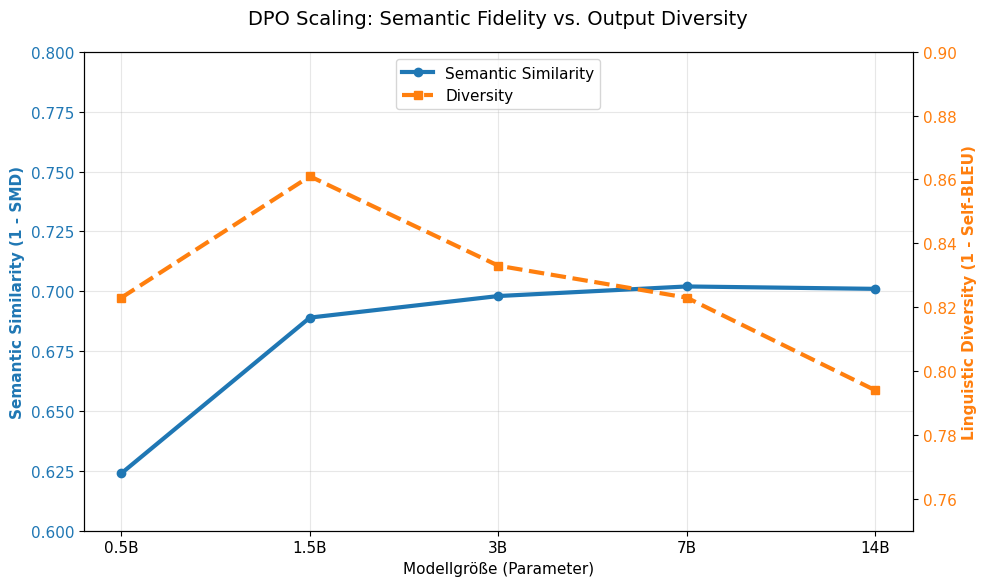

In [4]:
import matplotlib.pyplot as plt
import numpy as np

model_sizes = ['0.5B', '1.5B', '3B', '7B', '14B']
smd_values = np.array([0.376, 0.311, 0.302, 0.298, 0.299])
self_bleu_values = np.array([0.177, 0.139, 0.167, 0.177, 0.206])

semantic_similarity = 1 - smd_values          
linguistic_diversity = 1 - self_bleu_values   

fig, ax1 = plt.subplots(figsize=(10, 6))

color_sim = 'tab:blue'
ax1.set_xlabel('Modellgröße (Parameter)')
ax1.set_ylabel('Semantic Similarity (1 - SMD)', color=color_sim, fontweight='bold')
line1 = ax1.plot(model_sizes, semantic_similarity, color=color_sim, marker='o', linewidth=3, label='Semantic Similarity')
ax1.tick_params(axis='y', labelcolor=color_sim)
ax1.set_ylim(0.6, 0.8) # Zoom auf den relevanten Bereich

ax2 = ax1.twinx()
color_div = 'tab:orange'
ax2.set_ylabel('Linguistic Diversity (1 - Self-BLEU)', color=color_div, fontweight='bold')
line2 = ax2.plot(model_sizes, linguistic_diversity, color=color_div, marker='s', linestyle='--', linewidth=3, label='Diversity')
ax2.tick_params(axis='y', labelcolor=color_div)
ax2.set_ylim(0.75, 0.9)

plt.title('DPO Scaling: Semantic Fidelity vs. Output Diversity', pad=20, fontsize=14)
ax1.grid(True, alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

plt.tight_layout()
plt.show()

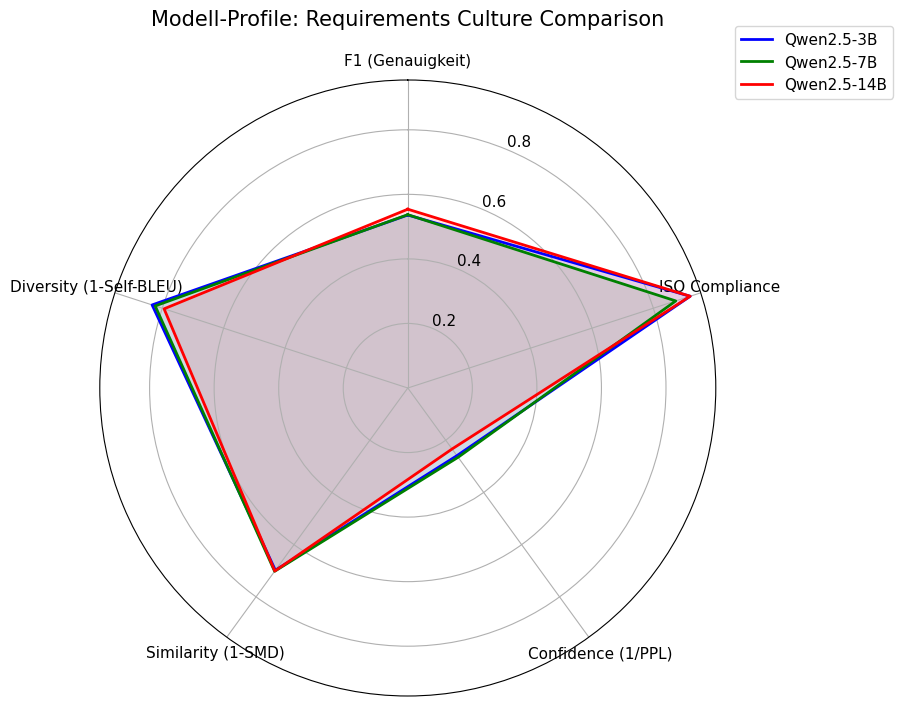

In [6]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['F1 (Genauigkeit)', 'ISO Compliance', 'Confidence (1/PPL)', 
          'Similarity (1-SMD)', 'Diversity (1-Self-BLEU)']
num_vars = len(labels)

stats_3B = [0.536, 0.920, 1/3.859, 1-0.302, 1-0.167]
# 7B: Der Allrounder
stats_7B = [0.537, 0.873, 1/3.770, 1-0.298, 1-0.177]
# 14B: Der Spezialist für Strenge
stats_14B = [0.554, 0.920, 1/4.282, 1-0.299, 1-0.206]

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
stats_3B += stats_3B[:1]
stats_7B += stats_7B[:1]
stats_14B += stats_14B[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.fill(angles, stats_3B, color='blue', alpha=0.1)
ax.plot(angles, stats_3B, color='blue', linewidth=2, label='Qwen2.5-3B')

ax.fill(angles, stats_7B, color='green', alpha=0.1)
ax.plot(angles, stats_7B, color='green', linewidth=2, label='Qwen2.5-7B')

ax.fill(angles, stats_14B, color='red', alpha=0.1)
ax.plot(angles, stats_14B, color='red', linewidth=2, label='Qwen2.5-14B')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title('Modell-Profile: Requirements Culture Comparison', size=15, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

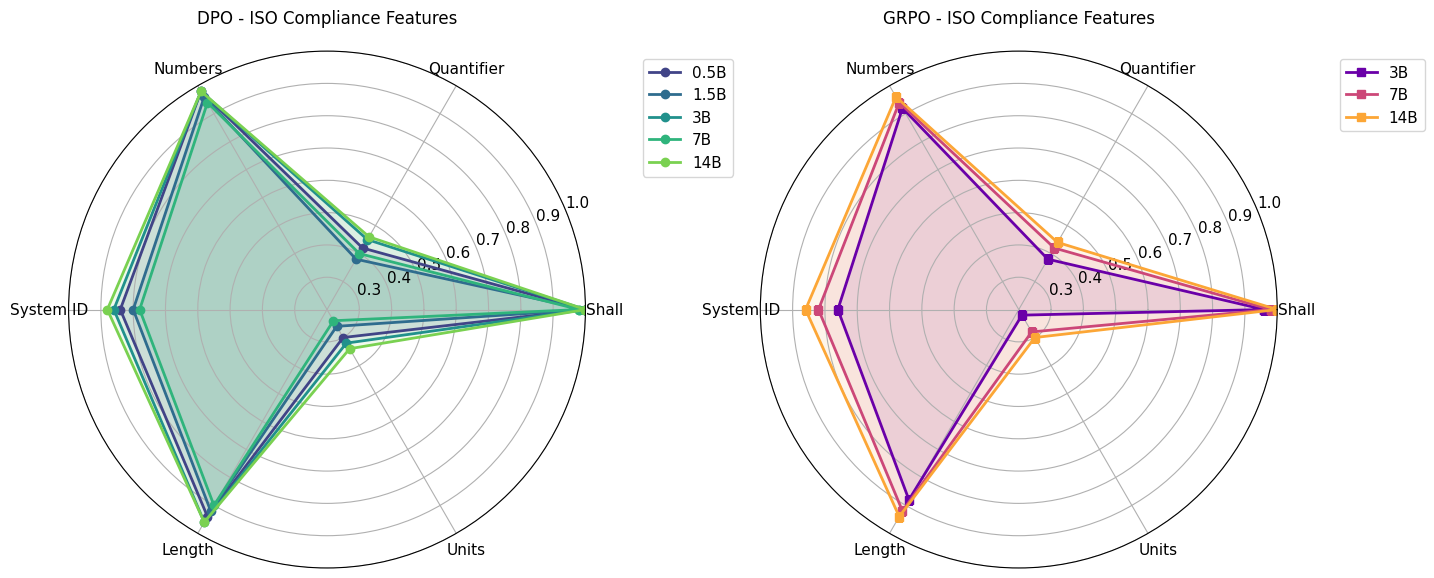

In [10]:
# FIGURE 4: Radar Chart - ISO Compliance Features (requires compliance breakdown)

compliance_breakdown_dpo = {
    '0.5B': [1.0, 0.42, 0.98, 0.84, 0.94, 0.30],
    '1.5B': [1.0, 0.38, 0.96, 0.80, 0.92, 0.26],
    '3B':   [1.0, 0.45, 0.98, 0.86, 0.96, 0.32],
    '7B':   [0.98, 0.40, 0.94, 0.78, 0.90, 0.24],
    '14B':  [1.0, 0.46, 0.98, 0.88, 0.96, 0.34]
}

compliance_breakdown_grpo = {
    '3B':  [0.96, 0.38, 0.92, 0.76, 0.88, 0.22],
    '7B':  [0.98, 0.42, 0.94, 0.82, 0.92, 0.28],
    '14B': [1.0, 0.44, 0.96, 0.86, 0.94, 0.30]
}

categories = ['Shall', 'Quantifier', 'Numbers', 'System ID', 'Length', 'Units']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

# DPO Radar
colors_dpo = plt.cm.viridis(np.linspace(0.2, 0.8, 5))
for i, (size, values) in enumerate(compliance_breakdown_dpo.items()):
    values_plot = values + values[:1]
    ax4a.plot(angles, values_plot, 'o-', linewidth=2, label=size, color=colors_dpo[i])
    ax4a.fill(angles, values_plot, alpha=0.1, color=colors_dpo[i])

ax4a.set_xticks(angles[:-1])
ax4a.set_xticklabels(categories)
ax4a.set_ylim(0.2, 1)
ax4a.set_title('DPO - ISO Compliance Features', pad=20)
ax4a.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

# GRPO Radar
colors_grpo = plt.cm.plasma(np.linspace(0.2, 0.8, 3))
for i, (size, values) in enumerate(compliance_breakdown_grpo.items()):
    values_plot = values + values[:1]
    ax4b.plot(angles, values_plot, 's-', linewidth=2, label=size, color=colors_grpo[i])
    ax4b.fill(angles, values_plot, alpha=0.1, color=colors_grpo[i])

ax4b.set_xticks(angles[:-1])
ax4b.set_xticklabels(categories)
ax4b.set_ylim(0.2, 1)
ax4b.set_title('GRPO - ISO Compliance Features', pad=20)
ax4b.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.savefig('fig4_radar_compliance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# FIGURE 4: Radar Chart - ISO Compliance Features (requires compliance breakdown)

compliance_breakdown_dpo = {
    '0.5B': [1.0, 0.42, 0.98, 0.84, 0.94, 0.30],
    '1.5B': [1.0, 0.38, 0.96, 0.80, 0.92, 0.26],
    '3B':   [1.0, 0.45, 0.98, 0.86, 0.96, 0.32],
    '7B':   [0.98, 0.40, 0.94, 0.78, 0.90, 0.24],
    '14B':  [1.0, 0.46, 0.98, 0.88, 0.96, 0.34]
}

compliance_breakdown_grpo = {
    '3B':  [0.96, 0.38, 0.92, 0.76, 0.88, 0.22],
    '7B':  [0.98, 0.42, 0.94, 0.82, 0.92, 0.28],
    '14B': [1.0, 0.44, 0.96, 0.86, 0.94, 0.30]
}

categories = ['Shall', 'Quantifier', 'Numbers', 'System ID', 'Length', 'Units']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

# DPO Radar
colors_dpo = plt.cm.viridis(np.linspace(0.2, 0.8, 5))
for i, (size, values) in enumerate(compliance_breakdown_dpo.items()):
    values_plot = values + values[:1]
    ax4a.plot(angles, values_plot, 'o-', linewidth=2, label=size, color=colors_dpo[i])
    ax4a.fill(angles, values_plot, alpha=0.1, color=colors_dpo[i])

ax4a.set_xticks(angles[:-1])
ax4a.set_xticklabels(categories)
ax4a.set_ylim(0, 1)
ax4a.set_title('DPO - ISO Compliance Features', pad=20)
ax4a.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

# GRPO Radar
colors_grpo = plt.cm.plasma(np.linspace(0.2, 0.8, 3))
for i, (size, values) in enumerate(compliance_breakdown_grpo.items()):
    values_plot = values + values[:1]
    ax4b.plot(angles, values_plot, 's-', linewidth=2, label=size, color=colors_grpo[i])
    ax4b.fill(angles, values_plot, alpha=0.1, color=colors_grpo[i])

ax4b.set_xticks(angles[:-1])
ax4b.set_xticklabels(categories)
ax4b.set_ylim(0, 1)
ax4b.set_title('GRPO - ISO Compliance Features', pad=20)
ax4b.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.savefig('fig4_radar_compliance.png', dpi=150, bbox_inches='tight')
plt.show()

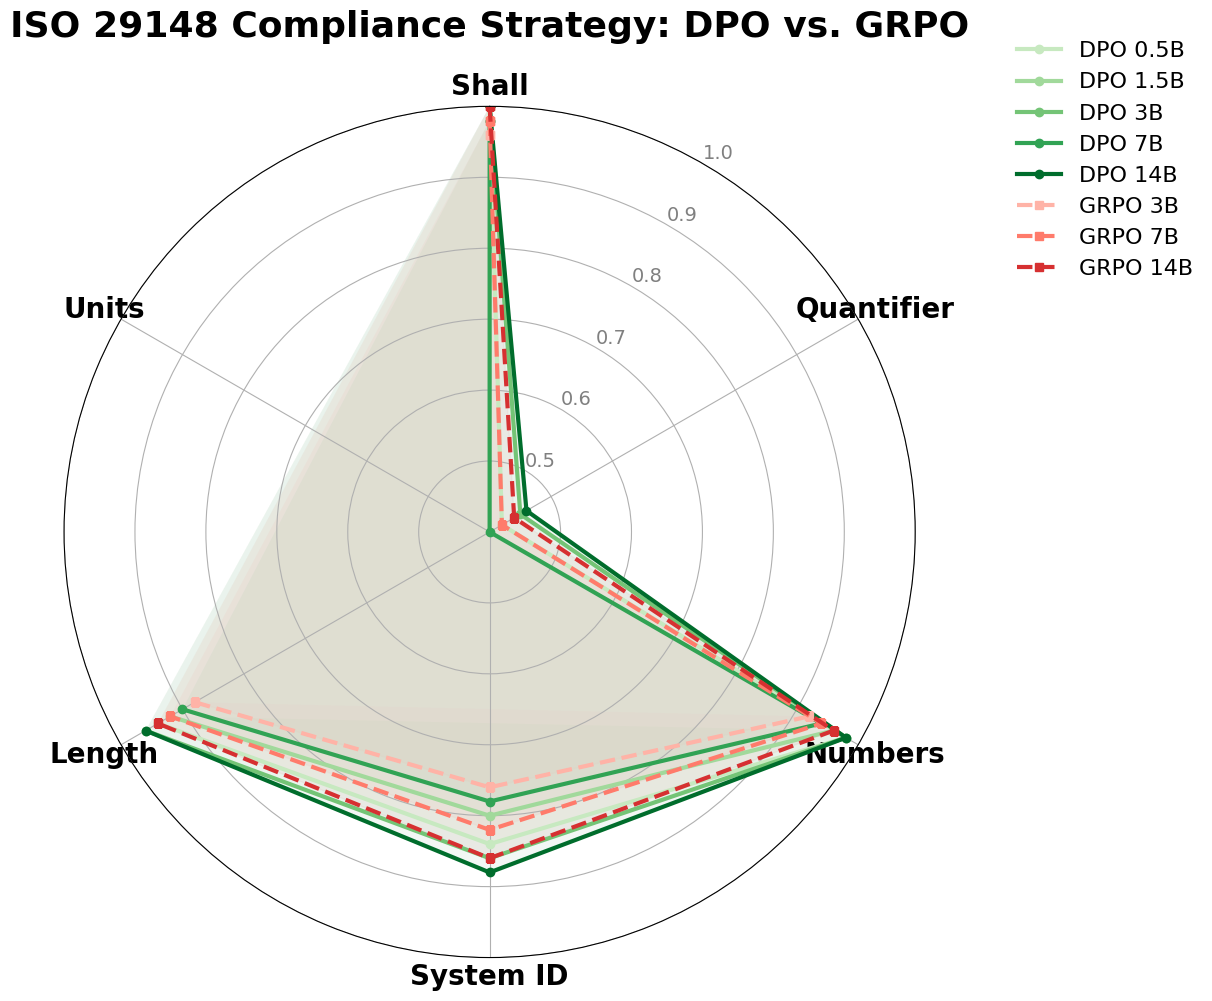

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

categories = ['Shall', 'Quantifier', 'Numbers', 'System ID', 'Length', 'Units']
N = len(categories)

compliance_breakdown_dpo = {
    '0.5B': [1.0, 0.42, 0.98, 0.84, 0.94, 0.30],
    '1.5B': [1.0, 0.38, 0.96, 0.80, 0.92, 0.26],
    '3B':   [1.0, 0.45, 0.98, 0.86, 0.96, 0.32],
    '7B':   [0.98, 0.40, 0.94, 0.78, 0.90, 0.24],
    '14B':  [1.0, 0.46, 0.98, 0.88, 0.96, 0.34]
}

compliance_breakdown_grpo = {
    '3B':   [0.96, 0.38, 0.92, 0.76, 0.88, 0.22],
    '7B':   [0.98, 0.42, 0.94, 0.82, 0.92, 0.28],
    '14B':  [1.0, 0.44, 0.96, 0.86, 0.94, 0.30]
}

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Kreisschluss

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

ax.set_ylim(0.4, 1.0) 

dpo_colors = ['#c7e9c0', '#a1d99b', '#74c476', '#31a354', '#006d2c']
grpo_colors = ['#ffb3a7', '#ff7b6b', '#d63031']

for i, (size, values) in enumerate(compliance_breakdown_dpo.items()):
    values_plot = values + values[:1]
    ax.plot(angles, values_plot, 'o-', linewidth=3, label=f'DPO {size}', color=dpo_colors[i])
    ax.fill(angles, values_plot, alpha=0.05, color=dpo_colors[i])

for i, (size, values) in enumerate(compliance_breakdown_grpo.items()):
    values_plot = values + values[:1]
    ax.plot(angles, values_plot, 's--', linewidth=3, label=f'GRPO {size}', color=grpo_colors[i])
    ax.fill(angles, values_plot, alpha=0.05, color=grpo_colors[i])

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, size=20, fontweight='bold')

ax.set_rlabel_position(30)
plt.yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0], ["0.5", "0.6", "0.7", "0.8", "0.9", "1.0"], color="grey", size=14)

plt.title('ISO 29148 Compliance Strategy: DPO vs. GRPO', size=26, pad=50, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=16, frameon=False)

plt.tight_layout()
plt.show()